In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
ROOT_DIR = '/content/gdrive/MyDrive/yolov8_verreo/'

In [ ]:
%cd {ROOT_DIR}

/content/gdrive/MyDrive/yolov8_verreo


In [ ]:
!git clone https://github.com/ultralytics/ultralytics.git

fatal: destination path 'ultralytics' already exists and is not an empty directory.


In [ ]:
%cd ultralytics

/content/gdrive/MyDrive/yolov8_verreo/ultralytics


In [ ]:
!pip install ultralytics

In [ ]:
%cd {ROOT_DIR}

/content/gdrive/MyDrive/yolov8_verreo


In [ ]:
!pip install Ipython

In [ ]:
!pip install roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="key")
project = rf.workspace("ai4industry-vxf2e").project("ai4i2")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
{dataset.location}

{'/content/gdrive/MyDrive/yolov8_verreo/ai4i2-1'}

## **Entrainement**

In [ ]:
!yolo task=detect mode=train model=yolov8s.pt data={dataset.location}/data.yaml epochs=20 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 21.5M/21.5M [00:00<00:00, 80.6MB/s]
Ultralytics 8.3.66 🚀 Python-3.11.11 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/data.yaml, epochs=20, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=va

## **Validation**

In [ ]:
!yolo task=detect mode=val model={ROOT_DIR}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.66 🚀 Python-3.11.11 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/valid/labels.cache... 16 images, 0 backgrounds, 0 corrupt: 100% 16/16 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 1/1 [00:16<00:00, 16.96s/it]
                   all         16         16      0.805      0.619      0.669      0.423
                Amorim          2          2          1       0.94      0.995      0.796
    CQ_Juan Costa Quer          2          2       0.82        0.5      0.578      0.347
                  DIAM          3          3      0.552      0.667      0.863       0.44
           JL_Ebrocork          5          5      0.457        0.8      0.566      0.328
              Nomacorc          3          3          1      0.805      0.995      0.611
             Trescases          1

## **Prédire**

In [ ]:
!yolo task=detect mode=predict model={ROOT_DIR}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images


Ultralytics 8.3.66 🚀 Python-3.11.11 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 168 layers, 11,128,680 parameters, 0 gradients, 28.5 GFLOPs

image 1/8 /content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/test/images/20240716112424621_0_jpg.rf.36fc1495d73197737f40e317359d296d.jpg: 640x640 1 DIAM, 627.0ms
image 2/8 /content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/test/images/Image_0007_20240829_170753_bmp.rf.2c2e685e106091e19b3f93d67e3ef035.jpg: 640x640 2 Nomacorcs, 620.5ms
image 3/8 /content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/test/images/Image_0036_20240829_165235_bmp.rf.e1976a62c35c1bc4c86d31b885cfd92f.jpg: 640x640 (no detections), 594.3ms
image 4/8 /content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/test/images/Image_0040_20240829_170005_bmp.rf.a8c4dbf70e9f3bc89f1d203bbd0206bb.jpg: 640x640 1 DIAM, 1 MASilva_Corticas, 587.8ms
image 5/8 /content/gdrive/MyDrive/yolov8_verreo/ai4i2-1/test/images/Image_0061_20240829_171010_bmp.rf.8c7c7744749e490cbac965948e0bd006.jpg: 640x640 (no de

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import Image as imgshow
import os

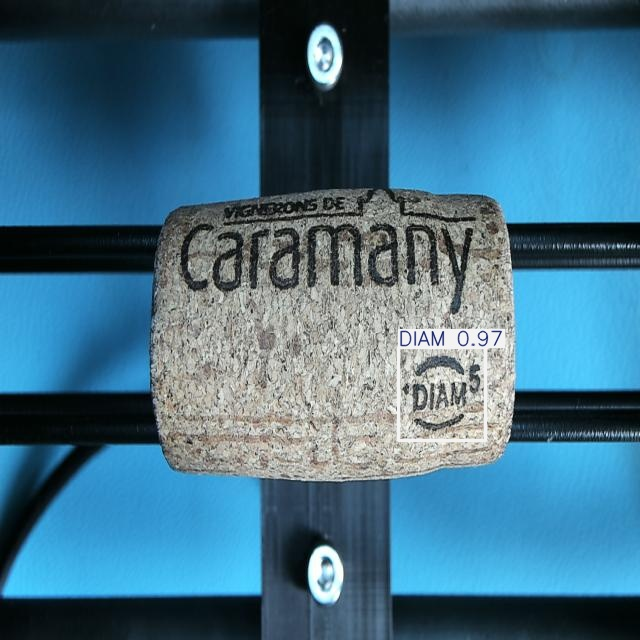

In [ ]:
imgshow(os.path.join(ROOT_DIR,"runs/detect/predict/20240716112424621_0_jpg.rf.36fc1495d73197737f40e317359d296d.jpg"), width = 600)

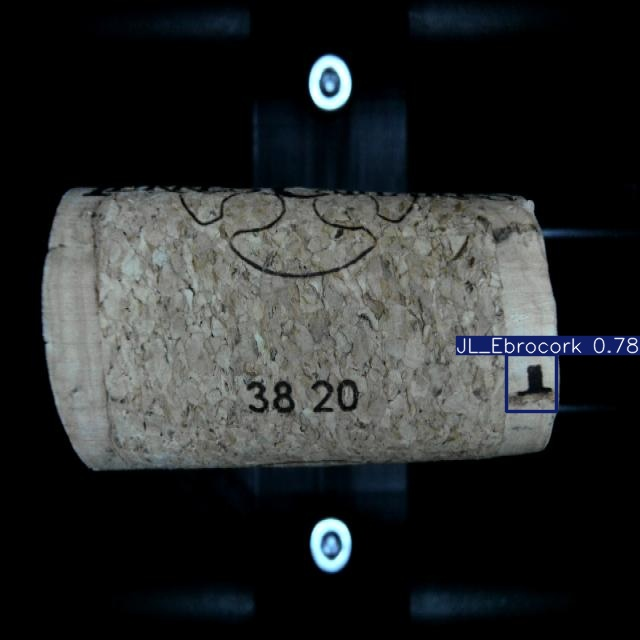

In [ ]:
imgshow(os.path.join(ROOT_DIR,"runs/detect/predict/Image_0081_20240829_165443_bmp.rf.de121f282eb5d863468d91c5770a0fd0.jpg"), width = 600)

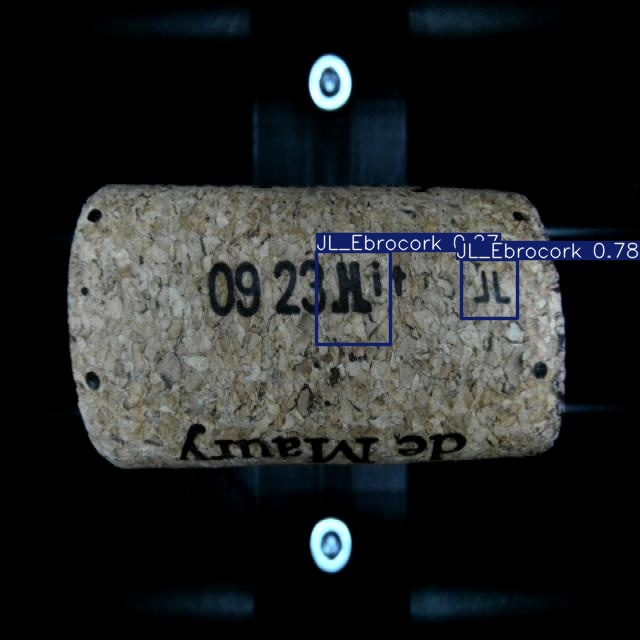

In [ ]:
imgshow(os.path.join(ROOT_DIR,"runs/detect/predict/Image_0094_20240829_165531_bmp.rf.bcd185c5d09f1ac3e65862017c86bf04.jpg"), width = 600)